# Association Rules

Association rules are a fundamental concept in data mining and machine learning, widely used to discover relationships and hidden patterns within large datasets. They are especially popular in market basket analysis, recommendation systems, and customer behavior analysis. Association rules aim to identify how items or events are related to one another by analyzing how frequently they occur together in transactions. These rules are typically expressed in the form “If X occurs, then Y is likely to occur,” helping organizations understand customer purchasing habits, improve product recommendations, and support strategic decision-making. Measures such as support, confidence, and lift are commonly used to evaluate the strength and relevance of these relationships.

<center><img src="../assets/imgs/apriori/Assoc_rulespng.png" alt="Association rules image"/><center/>


## African Usage

In Africa, association rules are increasingly applied across several sectors due to the rapid growth of digital technologies, mobile services, and data-driven systems. In retail and e-commerce, businesses use association rules to analyze customer purchasing behavior, optimize product placement, and create targeted promotions. For example, supermarkets may discover that customers who buy rice often also purchase cooking oil or beverages. In the banking and mobile money sector, association rules help identify transaction patterns, personalize financial services, and detect fraudulent activities. Telecommunications companies also use these techniques to study user behavior and recommend suitable data or call packages.

<center><img src="../assets/imgs/apriori/mobile.webp" alt="Association rules image"/><center/>


In agriculture, association rules support precision farming by identifying relationships between climate conditions, fertilizers, crop diseases, and harvest yields. Health institutions use them to analyze combinations of symptoms and improve disease prediction and diagnosis, particularly in epidemic monitoring. In education, they help identify learning patterns and student performance trends, while in transportation and urban planning, they contribute to traffic prediction and mobility optimization. Overall, association rules play an important role in Africa’s digital transformation by enabling organizations and governments to make smarter, data-driven decisions.


<center><img src="../assets/imgs/apriori/Agri.jpg" alt="Association rules image"/><center/>


## Key Concepts

### Itemset / Frequent Itemset



**Itemset**:  
An itemset is a collection of one or more items that appear together in a transaction. For example, in market basket analysis, an itemset could be a set of products purchased in the same transaction.

**Frequent Itemset**:  
A frequent itemset is an itemset that appears in the dataset often enough, meaning its **support** exceeds a minimum threshold (`min_support`). Frequent itemsets are the foundation for generating meaningful association rules.

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Itemset `{milk, bread}` appears in 2 out of 3 transactions → **support = 2/3 ≈ 0.67**.  
- If `min_support = 0.5`, `{milk, bread}` is a **frequent itemset**.

> Note: Frequent itemsets are the foundation for generating association rules efficiently. Algorithms such as Apriori, Eclat, and FP-Growth mainly focus on discovering these frequent itemsets before association rules are derived from them.


### Support



**Support** measures how frequently an itemset appears in the dataset.  
It is defined as the proportion of transactions that contain the itemset.

**Formula**:  

$ \text{Support}(X) = \frac{\text{Number of transactions containing } X}{\text{Total number of transactions}} $

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Consider the itemset `{milk, bread}`.  
- It appears in Transaction 1 and 2 → 2 out of 3 transactions.  
- **Support({milk, bread}) = 2 / 3 ≈ 0.67**

> Support is used in association rule mining algorithms such as Apriori, Eclat, and FP-Growth to filter out itemsets that are too rare, keeping only those that satisfy the minimum support (`min_support`) threshold.



**Confidence** measures how likely the consequent (Y) is purchased when the antecedent (X) is purchased.  
It is a conditional probability that quantifies the strength of an association rule.

**Formula**:  


$ \text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}
 $

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Consider the rule `{milk} → {bread}`.  
- `{milk}` appears in Transaction 1 and 2 → support(X) = 2/3 ≈ 0.67  
- `{milk, bread}` appears in Transaction 1 and 2 → support(X ∪ Y) = 2/3 ≈ 0.67  
- **Confidence({milk} → {bread}) = 0.67 / 0.67 = 1.0**

> Confidence tells us how reliable a rule is: a higher value indicates that the rule occurs frequently when X occurs.

**Lift** measures how much the presence of the antecedent (X) increases the probability of the consequent (Y) compared to when Y occurs independently.  
It helps identify rules that are more interesting than random co-occurrence.

**Formula**:  

$
 \text{Lift}(X \rightarrow Y) = \frac{\text{Confidence}(X \rightarrow Y)}{\text{Support}(Y)}
 $

**Interpretation**:  
- Lift > 1 → X and Y are positively correlated (occurs together more often than expected)  
- Lift = 1 → X and Y are independent  
- Lift < 1 → X and Y are negatively correlated (occurs together less often than expected)  

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Rule: `{milk} → {bread}`  
- Support({bread}) = 3/3 = 1.0  
- Confidence({milk} → {bread}) = 1.0 (from previous example)  
- **Lift({milk} → {bread}) = 1.0 / 1.0 = 1.0**

> Lift provides insight into the strength of a rule relative to the baseline occurrence of the consequent.

### Conviction (Optional)


**Conviction** is an optional metric that measures the degree of implication of a rule, penalizing rules that fail more often.  
It compares the expected frequency of the consequent occurring **without** the antecedent to the observed frequency when the antecedent occurs.

**Formula**:  

$ 
\text{Conviction}(X \rightarrow Y) = \frac{1 - \text{Support}(Y)}{1 - \text{Confidence}(X \rightarrow Y)}
 $

**Interpretation**:  
- Conviction > 1 → the rule has a positive implication; the higher, the stronger the rule.  
- Conviction ≈ 1 → the antecedent has little or no effect on the consequent.  
- Conviction < 1 → the rule is negatively correlated.

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Rule: `{milk} → {bread}`  
- Support({bread}) = 3/3 = 1.0  
- Confidence({milk} → {bread}) = 1.0  
- **Conviction({milk} → {bread}) = (1 - 1.0) / (1 - 1.0) = undefined** (perfect confidence gives infinite conviction)

> Conviction is especially useful for identifying strong rules when confidence alone may not capture the rarity of the consequent.

### Generation of frequent itemsets

Frequent itemset mining algorithms aim to discover groups of items that appear together frequently in transactional datasets.
Algorithms such as **Apriori**, **ECLAT**, and **FP-Growth** all produce frequent itemsets, but they differ significantly in the way support is computed and how the search space is explored.

### Apriori

The **Apriori** algorithm performs a **breadth-first search (BFS)** over the itemset lattice.
It starts by finding frequent 1-itemsets, then iteratively generates candidate k-itemsets from frequent (k−1)-itemsets using the Apriori property:

> If an itemset is frequent, all of its subsets must also be frequent.

The algorithm proceeds in four main steps at each iteration:

1. Generate candidate k-itemsets from frequent (k−1)-itemsets.
2. Prune candidates having infrequent subsets.
3. Scan the transaction database to count candidate support.
4. Keep only candidates satisfying `min_support`.

Apriori is simple and interpretable, but repeated database scans and candidate generation can become expensive for dense datasets or large itemsets.

---

### ECLAT

**ECLAT** (**Equivalence Class Clustering and bottom-up Lattice Traversal**) uses a **depth-first search (DFS)** strategy with a **vertical database representation**.

Instead of storing transactions directly, ECLAT stores for each item the set of transaction IDs (`tidset`) in which the item appears:

```python
bread -> {0, 1, 3, 4}
milk  -> {0, 2, 3, 4}
```

Frequent itemsets are generated by intersecting tidsets:

```python
{bread} ∩ {milk} = {0, 3, 4}
```

The support of an itemset is therefore computed from the size of the intersection without rescanning the database.

ECLAT is generally faster than Apriori on small or medium datasets because:

* it avoids repeated database scans,
* support counting becomes set intersection operations,
* DFS exploration reduces candidate overhead.

However, large tidsets may increase memory consumption on very large datasets.

---

### FP-Growth

**FP-Growth** (**Frequent Pattern Growth**) avoids explicit candidate generation entirely.

The algorithm performs two passes over the dataset:

1. Count item frequencies and remove infrequent items.
2. Build a compact **FP-Tree** where transactions are inserted in descending frequency order.

Shared transaction prefixes are compressed into the tree structure, significantly reducing redundancy.

Mining is then performed recursively using:

* conditional pattern bases,
* conditional FP-Trees,
* pattern-growth expansion.

Unlike Apriori, FP-Growth does not generate large candidate sets explicitly, making it highly efficient on dense datasets with many frequent patterns.

---

Once frequent itemsets are extracted by any of these algorithms, they can be used to generate **association rules**.

For a frequent itemset:

$
{milk, bread, butter}
$

possible association rules include:

$
{milk, bread} \rightarrow {butter}
$

or

$
{milk} \rightarrow {bread, butter}
$

These rules are then evaluated using metrics such as:

* **support**,
* **confidence**,
* **lift**,
* and optionally **conviction**.

Therefore, Apriori, ECLAT, and FP-Growth are primarily frequent itemset mining algorithms, while association rule mining is a subsequent step derived from the discovered frequent patterns.


### Association Rules



Association rules are derived from **frequent itemsets** and describe relationships between items in a transactional dataset.  
A rule is usually written as:

$ 
X \rightarrow Y
 $

Where:  
- `X` is the **antecedent** (items already present)  
- `Y` is the **consequent** (items implied or likely to occur with X)

**Metrics used to evaluate rules**:

- **Support**: Frequency of transactions containing both X and Y  
  $ 
  \text{Support}(X \cup Y) = \frac{\text{Transactions containing } X \text{ and } Y}{\text{Total transactions}}
   $

- **Confidence**: Likelihood of Y occurring given X  
  $ 
  \text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}
   $

- **Lift**: Measures how much more often X and Y occur together than expected if independent  
  $ 
  \text{Lift}(X \rightarrow Y) = \frac{\text{Confidence}(X \rightarrow Y)}{\text{Support}(Y)}
   $

- **Conviction (optional)**: Strength of implication, penalizing rules that fail  
  $ 
  \text{Conviction}(X \rightarrow Y) = \frac{1 - \text{Support}(Y)}{1 - \text{Confidence}(X \rightarrow Y)}
   $

**Example**:

| Transaction | Items                  |
|------------|------------------------|
| 1          | milk, bread, butter    |
| 2          | milk, bread            |
| 3          | bread, butter          |

- Rule: `{milk} → {bread}`  
- Support = 2/3 ≈ 0.67  
- Confidence = 2/2 = 1.0  
- Lift = 1.0 / 1.0 = 1.0  
- Conviction = ∞ (since confidence = 1)

> Association rules help uncover patterns in data, such as products frequently bought together, and are the final output of algorithms like Apriori, FP-Growth, or ECLAT.

### Key Concept in Theory: Anti-Monotonicity of Support



A fundamental property used in frequent itemset mining is the **anti-monotonicity of support** (also called the **Apriori property**):

> If an itemset is not frequent, then none of its supersets can be frequent.

This property is central to algorithms such as **Apriori**, **ECLAT**, and **FP-Growth**, because it allows the search space to be reduced significantly during mining.

* **Apriori** uses it explicitly to prune candidate itemsets before support counting.
* **ECLAT** benefits from it while recursively intersecting transaction ID sets.
* **FP-Growth** applies it implicitly when constructing conditional FP-Trees and discarding infrequent branches.

Without this property, frequent itemset mining would require exploring an exponential number of possible item combinations, making the process computationally impractical for large datasets.


**Example**:

- Suppose `{milk, bread}` is **not frequent** (support < `min_support`).  
- Any larger itemset that contains `{milk, bread}`, e.g., `{milk, bread, butter}`, **cannot be frequent** either.  
- Therefore, the algorithm **skips** counting support for `{milk, bread, butter}`, saving computation.

> Anti-monotonicity is the theoretical principle that makes frequent itemset mining computationally feasible on large datasets.

## Implementation

For this implementation, we will use the Groceries dataset. 
The Groceries dataset is a widely used dataset in machine learning for market basket analysis. It contains 9,835 transactions from a grocery store. Each transaction includes one or more items purchased by a customer, such as milk, bread, or beer. There are over 100 unique products in total. The dataset is often used to discover frequent itemsets and association rules, making it ideal for demonstrating algorithms like Apriori.

- Samples (transactions): 9,835
- Features (items per transaction): variable, one or more items

### Getting frequent itemsets

In [2]:
import pandas as pd
from ifri_mini_ml_lib.association_rules import Apriori, Eclat, FPGrowth

df = pd .read_csv("../assets/datasets/groceries.csv")

# Transform the 'items' column to a list of items
df['items'] = df['items'].apply(lambda x: [item.strip() for item in x.strip('{}').replace('"','').split(',')])

# Transform the 'items' column to a list of items
transactions = df['items'].tolist()

# Vérification
df.head()

,items
0,"[citrus fruit, semi-finished bread, margarine,..."
1,"[tropical fruit, yogurt, coffee]"
2,[whole milk]
3,"[pip fruit, yogurt, cream cheese, meat spreads]"
4,"[other vegetables, whole milk, condensed milk,..."


#### With Apriori

In [3]:
# Create an instance of the Apriori class
model = Apriori( min_support=0.02, min_confidence=0.5)

# Fit the model to the transactions
model.fit(transactions)

print("Number of transactions:", model.n_transactions)
print("Execution time (seconds):", model.execution_time)

# Get the frequent itemsets
frequent_itemsets = model.get_frequent_itemsets()
print("Frequent Itemsets:")
frequent_itemsets

Number of transactions: 9835
Execution time (seconds): 1.3275065422058105
Frequent Itemsets:


,itemsets,support,length
0,(whole milk),0.255516,1
1,(other vegetables),0.193493,1
2,(rolls/buns),0.183935,1
3,(soda),0.174377,1
4,(yogurt),0.139502,1
...,...,...,...
117,"(tropical fruit, pip fruit)",0.020437,2
118,"(bottled beer, whole milk)",0.020437,2
119,"(other vegetables, butter)",0.020031,2
120,"(whole milk, other vegetables, root vegetables)",0.023183,3


#### With Eclat

In [4]:
# Create an instance of the Eclat class
model = Eclat( min_support=0.02, min_confidence=0.5)

# Fit the model to the transactions
model.fit(transactions)

print("Number of transactions:", model.n_transactions)
print("Execution time (seconds):", model.execution_time)

# Get the frequent itemsets
frequent_itemsets = model.get_frequent_itemsets()
print("Frequent Itemsets:")
frequent_itemsets

Number of transactions: 9835
Execution time (seconds): 0.06486821174621582
Frequent Itemsets:


,itemsets,support,length
0,(whole milk),0.255516,1
1,(other vegetables),0.193493,1
2,(rolls/buns),0.183935,1
3,(soda),0.174377,1
4,(yogurt),0.139502,1
...,...,...,...
117,"(bottled beer, whole milk)",0.020437,2
118,"(frozen vegetables, whole milk)",0.020437,2
119,"(other vegetables, butter)",0.020031,2
120,"(whole milk, root vegetables, other vegetables)",0.023183,3


### With FPGrowth

In [5]:
# Create an instance of the FPGrowth class
model = FPGrowth( min_support=0.02, min_confidence=0.5)

# Fit the model to the transactions
model.fit(transactions)
print("Number of transactions:", model.n_transactions)
print("Execution time (seconds):", model.execution_time)

# Get the frequent itemsets
frequent_itemsets = model.get_frequent_itemsets()
print("Frequent Itemsets:")
frequent_itemsets

Number of transactions: 9835
Execution time (seconds): 0.28333401679992676
Frequent Itemsets:


,itemsets,support,length
0,(whole milk),0.255516,1
1,(other vegetables),0.193493,1
2,(rolls/buns),0.183935,1
3,(soda),0.174377,1
4,(yogurt),0.139502,1
...,...,...,...
117,"(tropical fruit, pip fruit)",0.020437,2
118,"(bottled beer, whole milk)",0.020437,2
119,"(other vegetables, butter)",0.020031,2
120,"(whole milk, other vegetables, root vegetables)",0.023183,3


### Making Association rules

In [6]:
from ifri_mini_ml_lib.association_rules.association_rules import AssociationRules

In [7]:
# Create an instance of the association_rules class
rules = AssociationRules(min_confidence=0.5, min_lift=1.2)
# Fit the model to the transactions
rules_ = rules.generate_rules(frequent_itemsets)

In [8]:
# print the generated rules
rules_

,antecedents,consequents,antecedent_support,consequent_support,support,confidence,lift,conviction
0,"(yogurt, other vegetables)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,1.52834


In [9]:
print("Number of rules generated:", len(rules_))
print("Execution time (seconds):", rules.execution_time)

Number of rules generated: 1
Execution time (seconds): 0.02371072769165039


In [10]:
import ipywidgets as widgets
from IPython.display import display

In [11]:
def generate_rules(method, min_support, min_confidence, min_lift):
    
    if method == "apriori":
        model = Apriori(min_support=min_support, min_confidence=min_confidence)

    elif method == "eclat":
        model = Eclat(min_support=min_support, min_confidence=min_confidence)

    elif method == "fpgrowth":
        model = FPGrowth(min_support=min_support, min_confidence=min_confidence)

    else:
        raise ValueError("Unknown method")

    model.fit(transactions)
    frequent_itemsets = model.get_frequent_itemsets()

    rules = AssociationRules(min_confidence=min_confidence, min_lift=min_lift)
    rules_ = rules.generate_rules(frequent_itemsets)

    return rules_[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

In [ ]:
widgets.interact(
    generate_rules,
    method=widgets.Dropdown(
        options=["apriori", "eclat", "fpgrowth"],
        value="apriori",
        description="Algo"
    ),
    min_support=widgets.FloatSlider(value=0.02, min=0.001, max=0.1, step=0.005),
    min_confidence=widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.05),
    min_lift=widgets.FloatSlider(value=1.2, min=0.5, max=3.0, step=0.1)
)

interactive(children=(Dropdown(description='Algo', options=('apriori', 'eclat', 'fpgrowth'), value='apriori'),…

<function __main__.generate_rules(method, min_support, min_confidence, min_lift)>

## Benchmarking

In [13]:
from utils import benchmark_all, plot_results

# Run benchmark
results_df = benchmark_all(
    transactions,
    min_support=0.02,
    min_conf=0.5,
    min_lift=1.0,
    n_runs=5
)

# Print results
results_df

,model,avg_time_sec,std_time_sec,min_time_sec,max_time_sec,avg_memory_MB,peak_memory_MB,avg_n_rules,avg_confidence,avg_lift,speedup_vs_ifri_apriori,efficiency_score
0,IFRI Apriori,2.015241,0.018737,1.986661,2.042179,209.518750,209.523438,1.0,0.512881,2.007235,1.000000,0.996027
1,IFRI ECLAT,0.757391,0.008792,0.746640,0.766625,209.787500,209.937500,1.0,0.512881,2.007235,2.660766,2.650195
2,IFRI FP-Growth,1.058464,0.128141,0.884330,1.213598,217.249219,219.441406,1.0,0.512881,2.007235,1.903930,1.896366
3,MLxtend Apriori,1.141541,0.258994,0.861933,1.549650,257.060156,264.152344,1.0,0.512881,2.007235,1.765369,1.758355
4,MLxtend FP-Growth,2.199778,0.126529,1.975277,2.337990,246.772656,259.835938,1.0,0.512881,2.007235,0.916111,0.912471


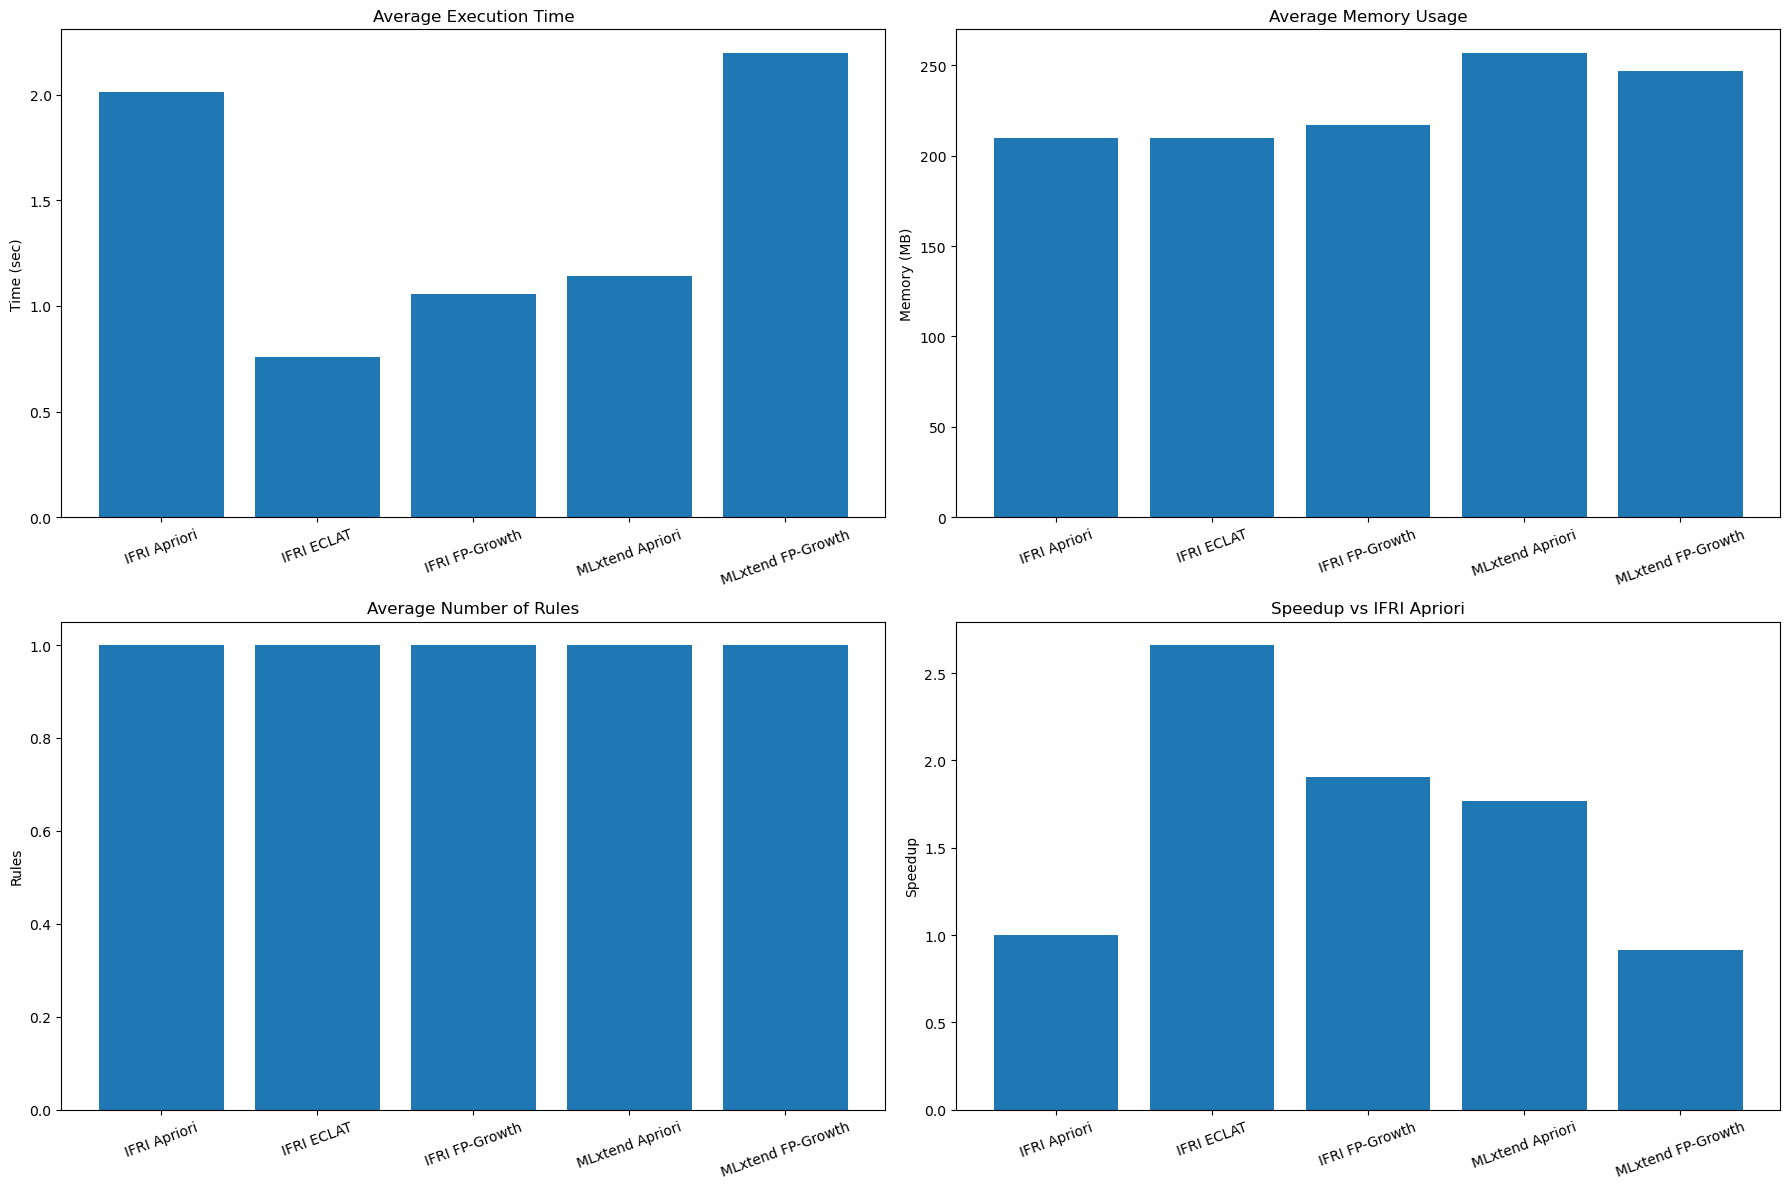

In [14]:
# Plot
plot_results(results_df)